<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°09

**Objetivo**: Aplicar un flujo completo de **Machine Learning supervisado** para la clasificación de tumores mamarios, utilizando técnicas de preprocesamiento, reducción de dimensionalidad y modelos de clasificación con optimización de hiperparámetros.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.





<img src="https://www.svgrepo.com/show/1064/virus.svg" width = "300" align="center"/>



El **cáncer de mama** es una enfermedad caracterizada por la proliferación maligna de células epiteliales en los conductos o lobulillos mamarios. Surge cuando una célula acumula mutaciones que le otorgan la capacidad de dividirse de manera descontrolada, lo que da origen a un tumor. Este tumor puede permanecer localizado o, en casos más agresivos, invadir tejidos cercanos y propagarse a otras partes del organismo mediante metástasis.

El conjunto de datos **`BC.csv`** recopila información clínica y morfológica de pacientes con tumores mamarios, clasificados como **benignos** o **malignos**. Las características se obtienen a partir de imágenes digitalizadas de aspirados con aguja fina (FNA, por sus siglas en inglés) de masas mamarias. Dichas variables describen aspectos cuantitativos de los **núcleos celulares**, como su tamaño, forma, textura y homogeneidad.

Este tipo de información es fundamental para la detección temprana y clasificación de tumores, ya que permite entrenar modelos de **machine learning** capaces de apoyar el diagnóstico y diferenciar entre tumores benignos y malignos con mayor precisión.

A continuación, se procederá a cargar y explorar el conjunto de datos:



In [11]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas de Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuración de gráficos
%matplotlib inline
sns.set_palette("deep", desat=0.6)
sns.set(rc={'figure.figsize': (11.7, 8.27)})

# Cargar y preparar los datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/BC.csv")
df.set_index('id', inplace=True)

# Transformación de la variable objetivo
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Visualizar las primeras filas del DataFrame
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Con base en la información presentada, resuelva las siguientes tareas. Asegúrese de:

* Incluir el **código necesario** para ejecutar cada análisis.
* Explicar de manera **clara y fundamentada** los resultados obtenidos.
* Describir el **proceso seguido**, justificando las decisiones tomadas en cada etapa (preprocesamiento, elección de técnicas y parámetros, interpretación de resultados).





1. **Análisis exploratorio profundo (EDA):**

   * Examine la distribución de las variables, identifique valores atípicos y analice la correlación entre características.
   * Visualice las diferencias más relevantes entre tumores **benignos** y **malignos** utilizando gráficos adecuados (boxplots, histogramas, mapas de calor).
   * Discuta qué variables parecen tener mayor capacidad discriminativa.


Dimensiones del dataset:
(569, 31)

Primeras filas:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Información general:
<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  ar

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0



Filas duplicadas:
0

Distribución de la variable objetivo diagnosis:


,count
diagnosis,
Benigno,357
Maligno,212


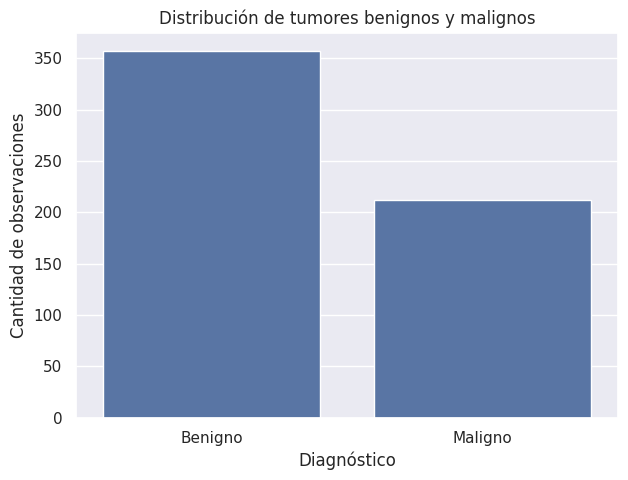


Resumen estadístico de variables predictoras:


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744



Top 10 variables con mayor diferencia relativa entre tumores benignos y malignos:


,media_benigno,media_maligno,diferencia_absoluta,diferencia_relativa
concavity_mean,0.046058,0.160775,0.114717,2.490730
area_se,21.135148,72.672406,51.537257,2.438462
concave points_mean,0.025717,0.087990,0.062273,2.421418
concavity_worst,0.166238,0.450606,0.284368,1.710610
area_worst,558.899440,1422.286321,863.386881,1.544798
concave points_worst,0.074444,0.182237,0.107793,1.447967
perimeter_se,2.000321,4.323929,2.323608,1.161617
radius_se,0.284082,0.609083,0.325000,1.144035
area_mean,462.790196,978.376415,515.586219,1.114082
compactness_worst,0.182673,0.374824,0.192152,1.051891


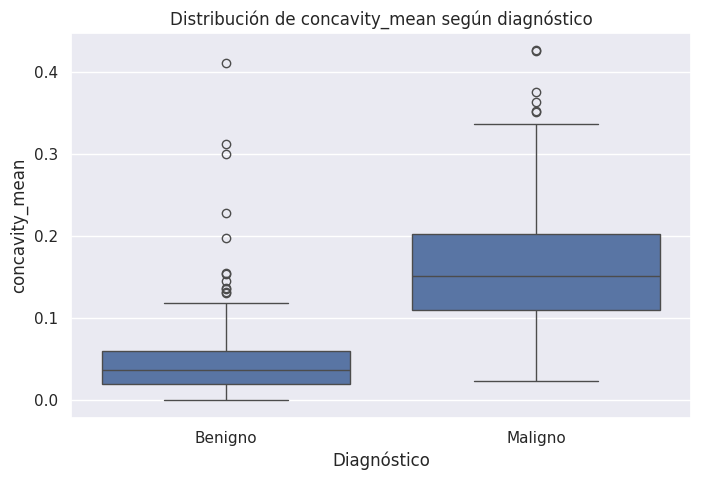

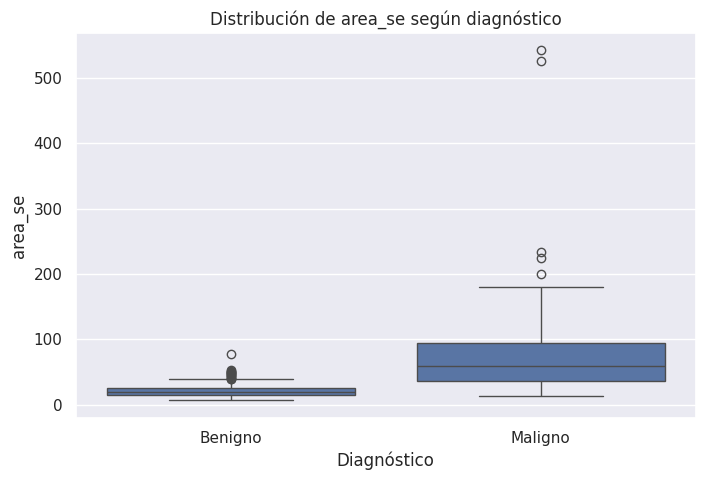

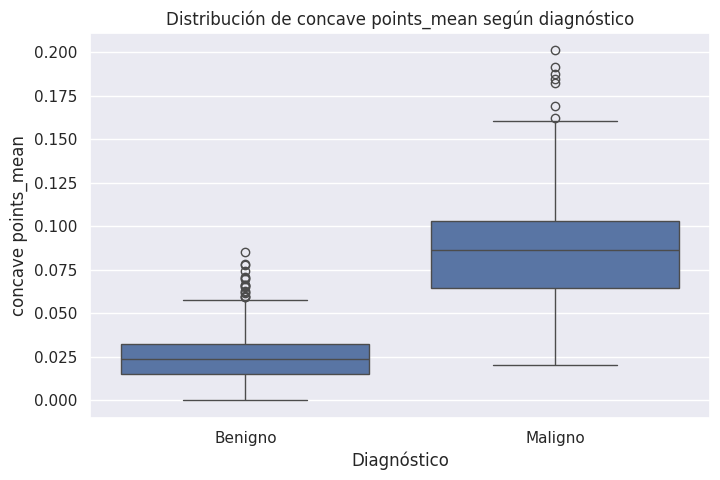

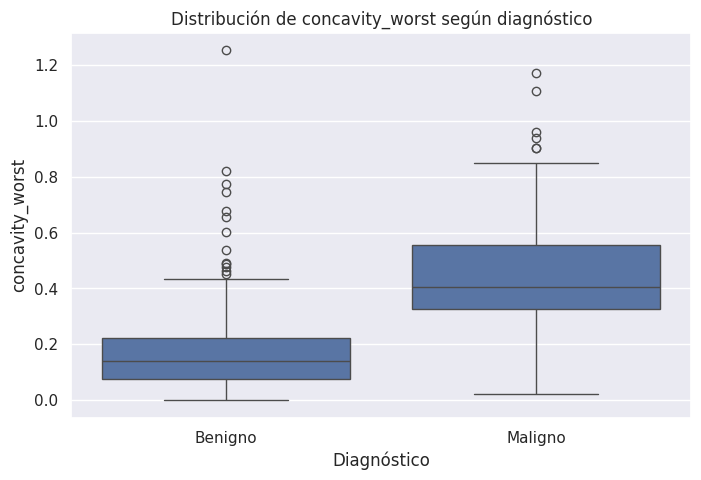

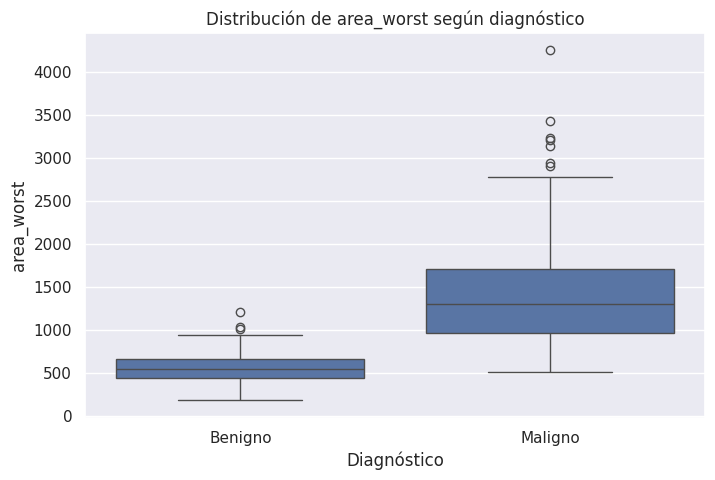

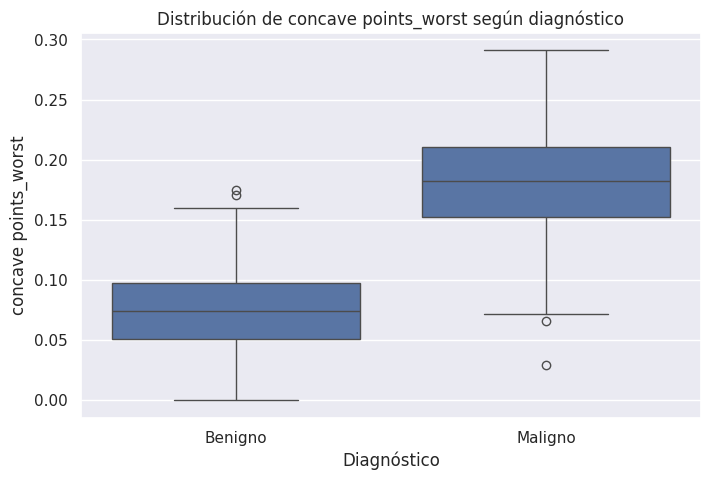

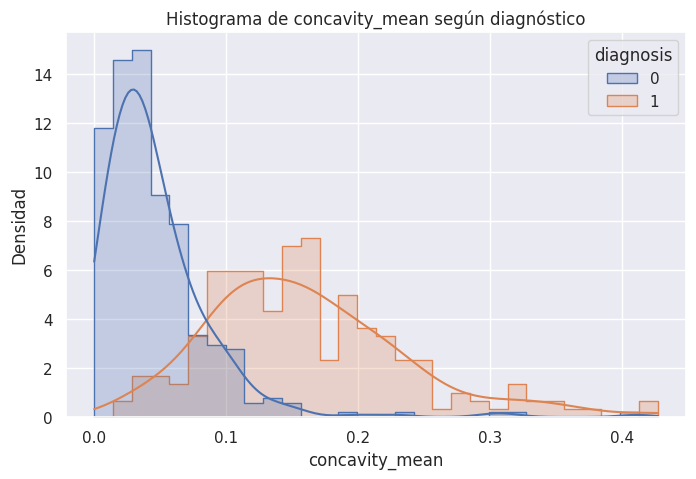

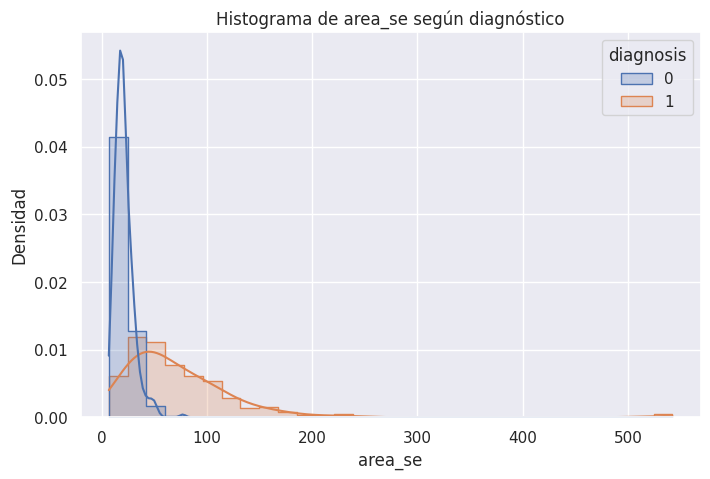

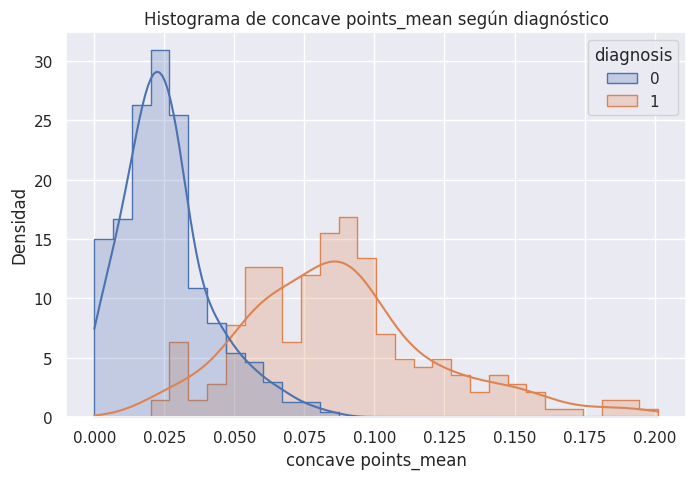

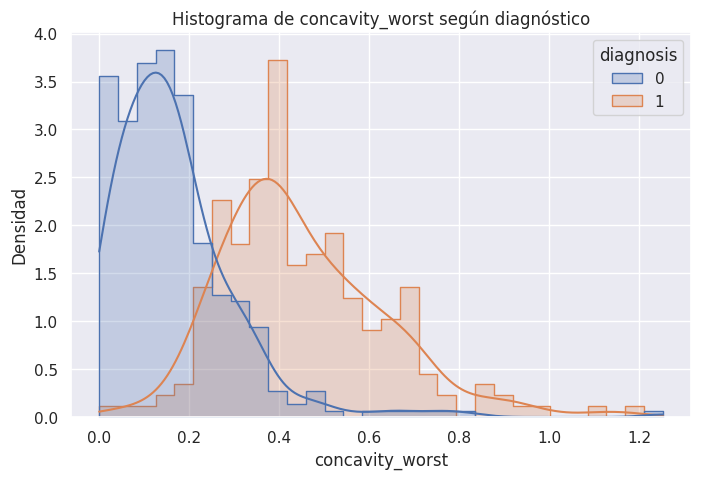

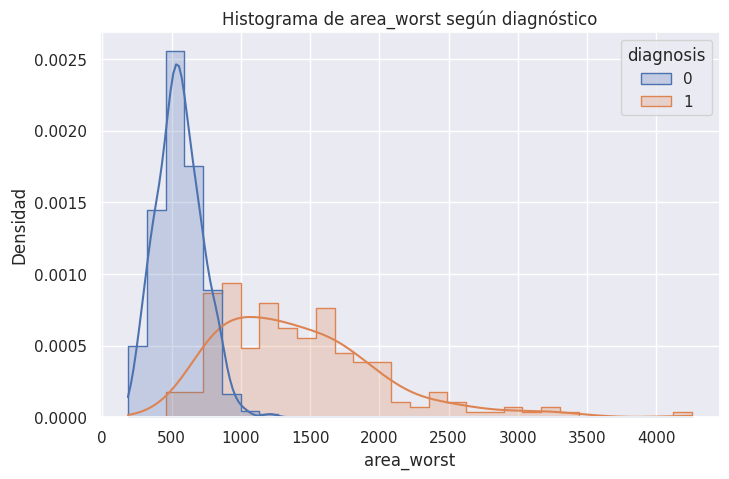

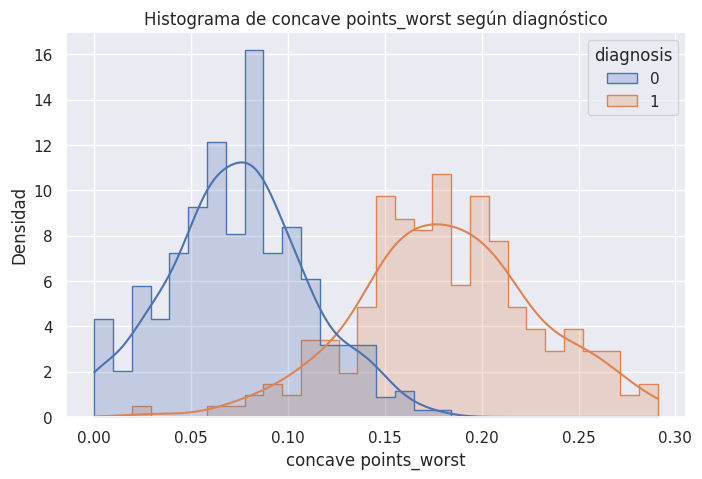

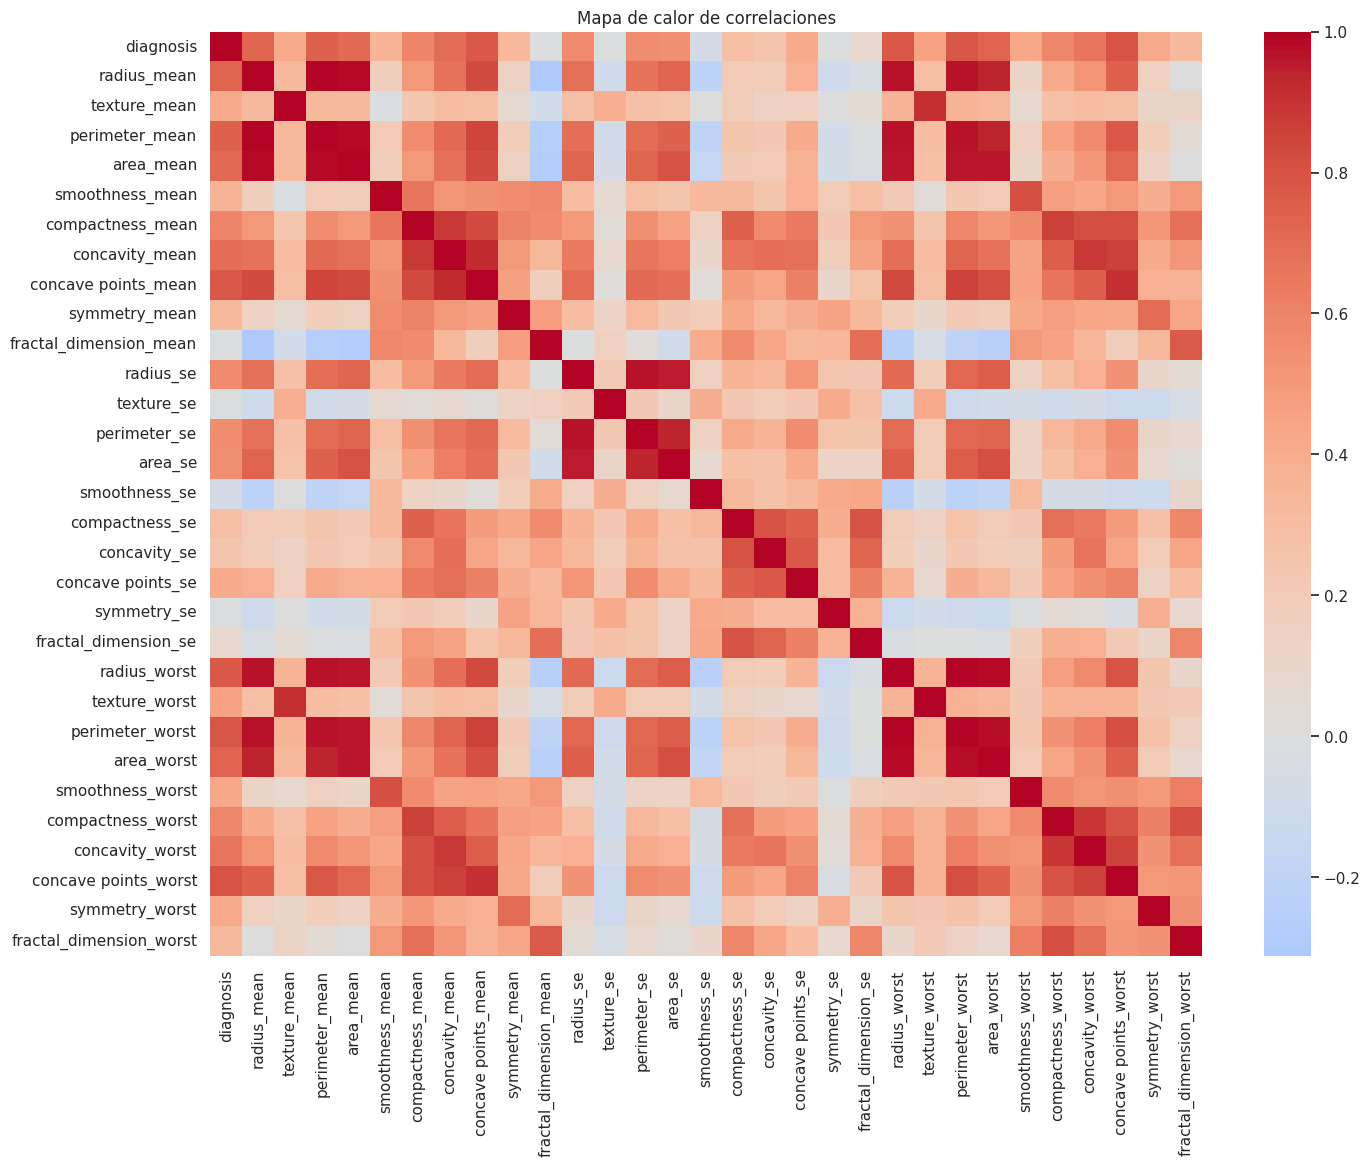


Variables más correlacionadas con diagnosis:


,diagnosis
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360
concavity_worst,0.659610


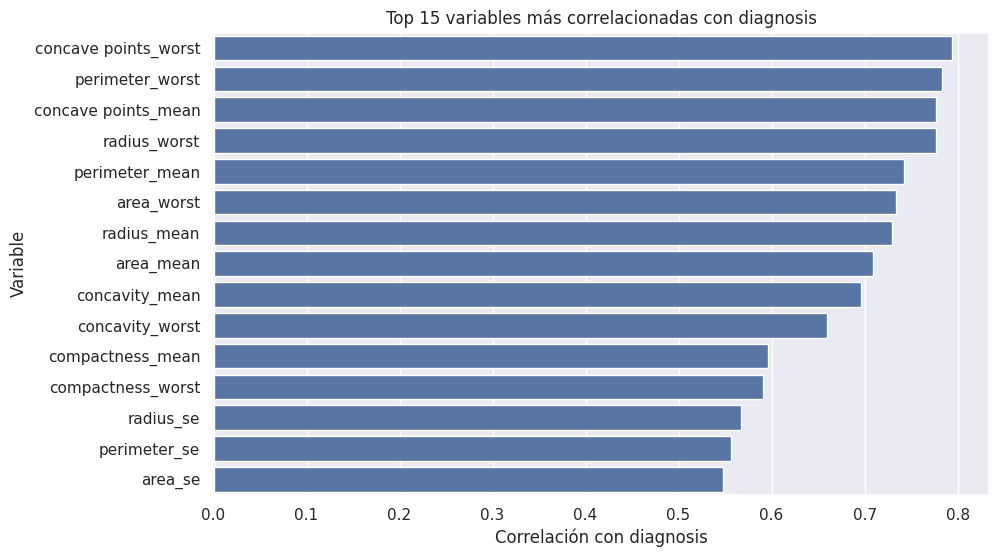


Variables con mayor proporción de valores atípicos según IQR:


,variable,outliers_iqr,porcentaje_outliers
13,area_se,65,11.42
10,radius_se,38,6.68
12,perimeter_se,38,6.68
23,area_worst,35,6.15
14,smoothness_se,30,5.27
19,fractal_dimension_se,28,4.92
15,compactness_se,28,4.92
18,symmetry_se,27,4.75
3,area_mean,25,4.39
29,fractal_dimension_worst,24,4.22


In [12]:
# 1. Análisis exploratorio profundo (EDA)

# Revisión general del dataset
print("Dimensiones del dataset:")
print(df.shape)

print("\nPrimeras filas:")
display(df.head())

print("\nInformación general:")
df.info()

print("\nValores nulos por columna:")
display(df.isnull().sum())

print("\nFilas duplicadas:")
print(df.duplicated().sum())

print("\nDistribución de la variable objetivo diagnosis:")
diagnosis_counts = df["diagnosis"].value_counts().sort_index()
diagnosis_labels = {0: "Benigno", 1: "Maligno"}
display(diagnosis_counts.rename(index=diagnosis_labels))

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="diagnosis")
plt.title("Distribución de tumores benignos y malignos")
plt.xlabel("Diagnóstico")
plt.ylabel("Cantidad de observaciones")
plt.xticks([0, 1], ["Benigno", "Maligno"])
plt.show()

# Separar variables predictoras y variable objetivo
X = df.drop(columns="diagnosis")
y = df["diagnosis"]

# Resumen estadístico
print("\nResumen estadístico de variables predictoras:")
display(X.describe().T)

# Variables con mayor diferencia relativa entre benignos y malignos
resumen_por_diagnostico = df.groupby("diagnosis")[X.columns].mean().T
resumen_por_diagnostico.columns = ["media_benigno", "media_maligno"]
resumen_por_diagnostico["diferencia_absoluta"] = (
    resumen_por_diagnostico["media_maligno"] - resumen_por_diagnostico["media_benigno"]
).abs()
resumen_por_diagnostico["diferencia_relativa"] = (
    resumen_por_diagnostico["diferencia_absoluta"] / resumen_por_diagnostico["media_benigno"].replace(0, np.nan)
)

variables_discriminativas = resumen_por_diagnostico.sort_values(
    "diferencia_relativa", ascending=False
).head(10)

print("\nTop 10 variables con mayor diferencia relativa entre tumores benignos y malignos:")
display(variables_discriminativas)

# Boxplots de variables más discriminativas
top_vars = variables_discriminativas.index.tolist()

for col in top_vars[:6]:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="diagnosis", y=col)
    plt.title(f"Distribución de {col} según diagnóstico")
    plt.xlabel("Diagnóstico")
    plt.ylabel(col)
    plt.xticks([0, 1], ["Benigno", "Maligno"])
    plt.show()

# Histogramas comparativos
for col in top_vars[:6]:
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=df,
        x=col,
        hue="diagnosis",
        kde=True,
        bins=30,
        element="step",
        stat="density",
        common_norm=False
    )
    plt.title(f"Histograma de {col} según diagnóstico")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.show()

# Matriz de correlación
corr = df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Mapa de calor de correlaciones")
plt.show()

# Correlación de variables con diagnosis
corr_diagnosis = (
    corr["diagnosis"]
    .drop("diagnosis")
    .sort_values(key=lambda x: abs(x), ascending=False)
)

print("\nVariables más correlacionadas con diagnosis:")
display(corr_diagnosis.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_diagnosis.head(15).values, y=corr_diagnosis.head(15).index)
plt.title("Top 15 variables más correlacionadas con diagnosis")
plt.xlabel("Correlación con diagnosis")
plt.ylabel("Variable")
plt.show()

# Detección simple de valores atípicos usando IQR
outlier_summary = []

for col in X.columns:
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((X[col] < lower) | (X[col] > upper)).sum()
    outlier_summary.append({
        "variable": col,
        "outliers_iqr": outliers,
        "porcentaje_outliers": round(outliers / len(X) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "porcentaje_outliers", ascending=False
)

print("\nVariables con mayor proporción de valores atípicos según IQR:")
display(outlier_summary.head(10))

El dataset contiene **569 observaciones** y **31 columnas**, donde `diagnosis` corresponde a la variable objetivo y las otras 30 variables describen características del tumor. No se observan valores nulos en ninguna columna y tampoco existen filas duplicadas, por lo que la base presenta una buena calidad inicial para el análisis.

La variable objetivo está compuesta por **357 tumores benignos** y **212 tumores malignos**. Esto muestra que existe cierto desbalance entre clases, ya que los casos benignos son más frecuentes, aunque la diferencia no es extrema. Por lo tanto, además del accuracy, es importante observar métricas como precision, recall y F1-score, especialmente para la clase maligna.

El análisis comparativo entre tumores benignos y malignos muestra que las variables con mayor diferencia relativa son `concavity_mean`, `area_se`, `concave points_mean`, `concavity_worst`, `area_worst` y `concave points_worst`. Esto indica que las características asociadas a la concavidad, puntos cóncavos, área y tamaño del tumor tienen alta capacidad discriminativa entre ambos diagnósticos.

La matriz de correlación confirma esta idea. Las variables más correlacionadas con `diagnosis` son `concave points_worst` con una correlación de **0,7936**, `perimeter_worst` con **0,7829**, `concave points_mean` con **0,7766**, `radius_worst` con **0,7765** y `perimeter_mean` con **0,7426**. En general, las variables relacionadas con tamaño, perímetro, radio, área, concavidad y puntos cóncavos presentan una relación importante con la probabilidad de que el tumor sea maligno.

También se detectaron valores atípicos mediante el criterio IQR. La variable con mayor proporción de outliers fue `area_se`, con **65 valores atípicos**, equivalentes al **11,42%** de la muestra. Luego aparecen `radius_se` y `perimeter_se`, ambas con **6,68%** de valores atípicos. Estos outliers no necesariamente deben eliminarse, ya que en un contexto médico pueden representar casos clínicamente relevantes.


2. **Preprocesamiento de datos:**

   * Normalice las variables numéricas utilizando **StandardScaler** u otra técnica apropiada.
   * Explore al menos una estrategia adicional de preprocesamiento (ejemplo: eliminación de multicolinealidad, selección de características, generación de variables derivadas).
   * Justifique sus elecciones.


In [13]:
# 2. Preprocesamiento de datos

# Separar variables predictoras y objetivo
X = df.drop(columns="diagnosis")
y = df["diagnosis"]

# Verificar nulos
print("Valores nulos en X:")
display(X.isnull().sum().sort_values(ascending=False).head())

# Estandarización con StandardScaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X.columns,
    index=X.index
)

print("\nMedia aproximada después de escalar:")
display(X_scaled.mean().round(4).head())

print("\nDesviación estándar aproximada después de escalar:")
display(X_scaled.std().round(4).head())

# Estrategia adicional: eliminación de multicolinealidad
# Se eliminan variables con correlación absoluta superior a 0.95 con otra variable.
corr_matrix = X_scaled.corr().abs()

upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper_tri.columns
    if any(upper_tri[column] > 0.95)
]

print("\nVariables eliminadas por alta multicolinealidad (> 0.95):")
print(to_drop)

X_scaled_reduced = X_scaled.drop(columns=to_drop)

print("\nDimensiones antes de eliminar multicolinealidad:")
print(X_scaled.shape)

print("\nDimensiones después de eliminar multicolinealidad:")
print(X_scaled_reduced.shape)

# División train-test usando el conjunto reducido
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTamaño de entrenamiento:")
print(X_train.shape)

print("\nTamaño de test:")
print(X_test.shape)

# Guardar nombres de variables finales
features_finales = X_scaled_reduced.columns.tolist()

print("\nVariables finales para modelamiento:")
print(features_finales)

Valores nulos en X:


,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0



Media aproximada después de escalar:


,0
radius_mean,-0.0
texture_mean,0.0
perimeter_mean,-0.0
area_mean,-0.0
smoothness_mean,-0.0



Desviación estándar aproximada después de escalar:


,0
radius_mean,1.0009
texture_mean,1.0009
perimeter_mean,1.0009
area_mean,1.0009
smoothness_mean,1.0009



Variables eliminadas por alta multicolinealidad (> 0.95):
['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']

Dimensiones antes de eliminar multicolinealidad:
(569, 30)

Dimensiones después de eliminar multicolinealidad:
(569, 23)

Tamaño de entrenamiento:
(455, 23)

Tamaño de test:
(114, 23)

Variables finales para modelamiento:
['radius_mean', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


En el preprocesamiento se separaron las variables predictoras de la variable objetivo `diagnosis`. Se verificó que las variables explicativas no presentan valores nulos, por lo que no fue necesario aplicar imputación.

Luego, las variables numéricas fueron estandarizadas mediante `StandardScaler`. Después del escalamiento, las medias de las variables quedan aproximadamente en **0** y las desviaciones estándar cercanas a **1**. Esto es importante porque varios modelos, como Regresión Logística, SVM y KNN, son sensibles a la escala de las variables.

Como estrategia adicional, se eliminó multicolinealidad entre variables. Para ello, se identificaron variables con correlación absoluta superior a **0,95** respecto de otra variable. Las variables eliminadas fueron `perimeter_mean`, `area_mean`, `perimeter_se`, `area_se`, `radius_worst`, `perimeter_worst` y `area_worst`.

Con esta reducción, el conjunto pasó de **30 variables predictoras** a **23 variables finales**. Esta decisión permite disminuir redundancia, simplificar el modelo y evitar que variables muy similares entreguen información repetida. Finalmente, el dataset fue dividido en **455 observaciones de entrenamiento** y **114 observaciones de prueba**, manteniendo una estructura adecuada para evaluar los modelos.


3. **Reducción de dimensionalidad:**

   * Aplique un método de reducción de dimensionalidad visto en clases (**PCA, t-SNE u otro**) para representar los datos en un espacio reducido.
   * Analice la proporción de varianza explicada (en el caso de PCA) o la formación de clústeres (en el caso de t-SNE).
   * Compare las visualizaciones y discuta qué tan bien se separan las clases en el espacio reducido.


Varianza explicada por componente:


,componente,varianza_explicada,varianza_acumulada
0,1,0.430865,0.430865
1,2,0.142424,0.573289
2,3,0.106859,0.680148
3,4,0.080089,0.760237
4,5,0.067037,0.827274
5,6,0.052324,0.879598
6,7,0.022138,0.901736
7,8,0.018995,0.920732
8,9,0.015686,0.936418
9,10,0.012431,0.948849


Componentes necesarios para explicar al menos 90% de la varianza: 7
Componentes necesarios para explicar al menos 95% de la varianza: 11


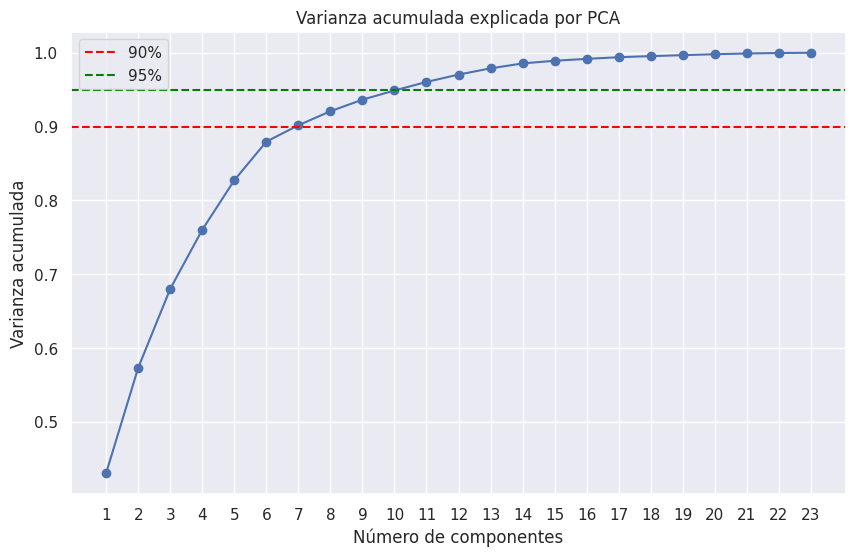

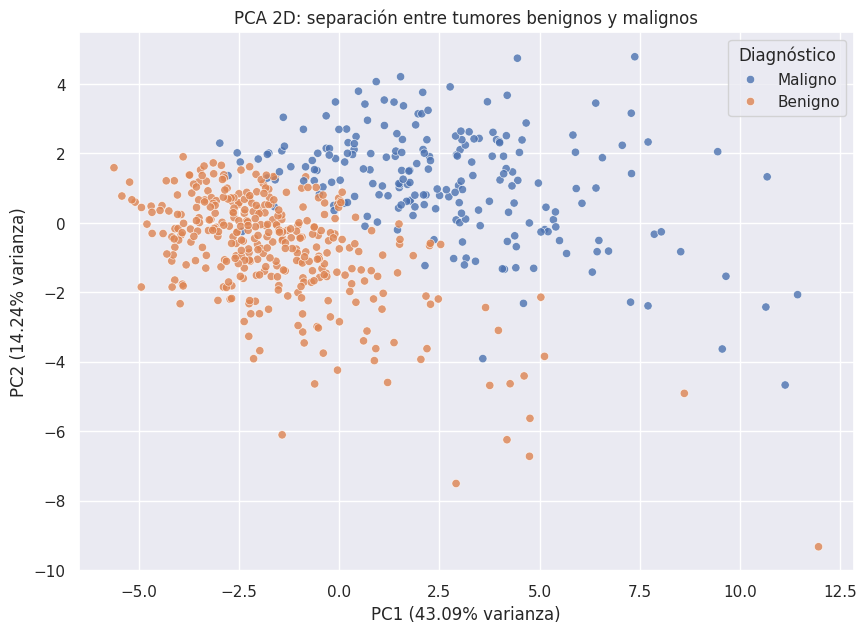


Variables con mayor peso absoluto en PC1:


,PC1
compactness_mean,0.301115
concavity_mean,0.292970
concavity_worst,0.279463
compactness_worst,0.273555
concave points_worst,0.268663
concave points_mean,0.265786
compactness_se,0.249209
concave points_se,0.231180
fractal_dimension_worst,0.228350
concavity_se,0.222007



Variables con mayor peso absoluto en PC2:


,PC2
radius_mean,0.403549
fractal_dimension_mean,0.375485
smoothness_se,0.339653
fractal_dimension_se,0.318429
symmetry_se,0.283818
concave points_worst,0.246899
texture_worst,0.225460
concave points_mean,0.223219
texture_mean,0.207084
compactness_se,0.178483


<Figure size 1200x600 with 0 Axes>

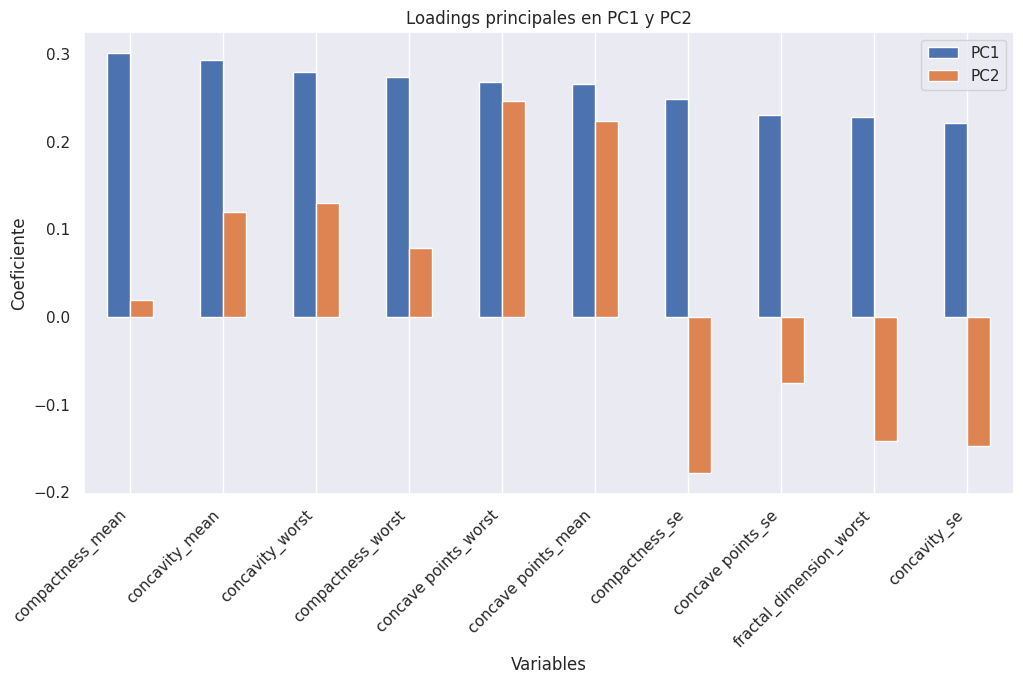

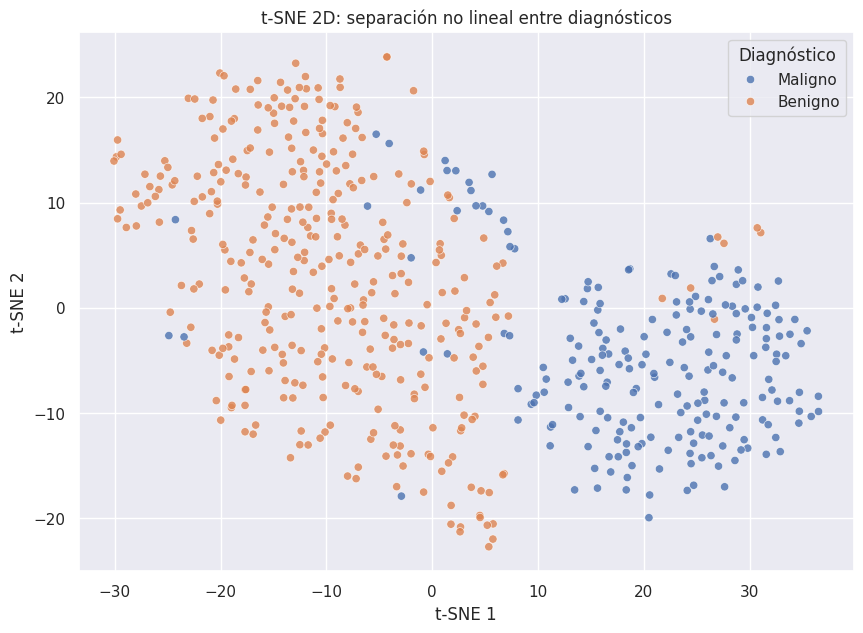

In [14]:
# 3. Reducción de dimensionalidad

# PCA con todos los componentes sobre variables ya escaladas y reducidas
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled_reduced)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

df_pca_var = pd.DataFrame({
    "componente": np.arange(1, len(varianza_explicada) + 1),
    "varianza_explicada": varianza_explicada,
    "varianza_acumulada": varianza_acumulada
})

print("Varianza explicada por componente:")
display(df_pca_var)

n_90 = np.argmax(varianza_acumulada >= 0.90) + 1
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1

print(f"Componentes necesarios para explicar al menos 90% de la varianza: {n_90}")
print(f"Componentes necesarios para explicar al menos 95% de la varianza: {n_95}")

plt.figure(figsize=(10, 6))
plt.plot(df_pca_var["componente"], df_pca_var["varianza_acumulada"], marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90%")
plt.axhline(0.95, color="green", linestyle="--", label="95%")
plt.title("Varianza acumulada explicada por PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.xticks(df_pca_var["componente"])
plt.legend()
plt.grid(True)
plt.show()

# PCA a 2 componentes para visualización
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled_reduced)

df_pca_2 = pd.DataFrame(
    X_pca_2,
    columns=["PC1", "PC2"],
    index=X_scaled_reduced.index
)
df_pca_2["diagnosis"] = y.values
df_pca_2["diagnosis_label"] = df_pca_2["diagnosis"].map({0: "Benigno", 1: "Maligno"})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_pca_2,
    x="PC1",
    y="PC2",
    hue="diagnosis_label",
    alpha=0.8
)
plt.title("PCA 2D: separación entre tumores benignos y malignos")
plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.2f}% varianza)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.2f}% varianza)")
plt.legend(title="Diagnóstico")
plt.show()

# Loadings de PC1 y PC2
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1", "PC2"],
    index=X_scaled_reduced.columns
)

print("\nVariables con mayor peso absoluto en PC1:")
display(loadings["PC1"].abs().sort_values(ascending=False).head(10))

print("\nVariables con mayor peso absoluto en PC2:")
display(loadings["PC2"].abs().sort_values(ascending=False).head(10))

plt.figure(figsize=(12, 6))
loadings.loc[
    loadings["PC1"].abs().sort_values(ascending=False).head(10).index,
    ["PC1", "PC2"]
].plot(kind="bar", figsize=(12, 6))
plt.title("Loadings principales en PC1 y PC2")
plt.xlabel("Variables")
plt.ylabel("Coeficiente")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

# t-SNE como visualización no lineal adicional
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled_reduced)

df_tsne = pd.DataFrame(
    X_tsne,
    columns=["TSNE1", "TSNE2"],
    index=X_scaled_reduced.index
)
df_tsne["diagnosis"] = y.values
df_tsne["diagnosis_label"] = df_tsne["diagnosis"].map({0: "Benigno", 1: "Maligno"})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_tsne,
    x="TSNE1",
    y="TSNE2",
    hue="diagnosis_label",
    alpha=0.8
)
plt.title("t-SNE 2D: separación no lineal entre diagnósticos")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Diagnóstico")
plt.show()

Se aplicó PCA sobre las variables estandarizadas y reducidas luego de eliminar multicolinealidad. El primer componente principal explicó **43,09%** de la varianza total, mientras que el segundo componente explicó **14,24%**. En conjunto, los dos primeros componentes explican aproximadamente **57,33%** de la variabilidad de los datos.

Para explicar al menos **90%** de la varianza total se necesitan **7 componentes**, mientras que para superar el **95%** se requieren **11 componentes**. Esto indica que el dataset puede reducirse considerablemente respecto de las 23 variables finales, aunque dos componentes no son suficientes para conservar casi toda la información original.

La visualización en dos dimensiones mediante PCA permite observar una separación parcial entre tumores benignos y malignos. Aunque existe cierta superposición entre ambas clases, los puntos tienden a ordenarse en zonas distintas del plano, lo que indica que las variables originales contienen información útil para diferenciar los diagnósticos.

Los loadings muestran que las variables con mayor peso absoluto en PC1 son `compactness_mean`, `concavity_mean`, `concavity_worst`, `compactness_worst`, `concave points_worst` y `concave points_mean`. Esto sugiere que el primer componente está fuertemente asociado a características de compactación, concavidad y puntos cóncavos del tumor. En PC2 destacan `radius_mean`, `fractal_dimension_mean`, `smoothness_se`, `fractal_dimension_se` y `symmetry_se`, por lo que este componente captura una dimensión distinta relacionada con tamaño, textura geométrica y variabilidad de forma.

Además, t-SNE permitió visualizar la separación de forma no lineal. A diferencia de PCA, t-SNE no entrega ejes interpretables, pero ayuda a observar agrupamientos locales entre tumores benignos y malignos. En conjunto, PCA aporta interpretabilidad y t-SNE complementa con una visualización más flexible de la separación entre clases.


4. **Modelado y evaluación:**

   * Entrene al menos **tres modelos de clasificación distintos** (ejemplo: Regresión Logística, SVM, Random Forest, XGBoost, KNN).
   * Realice una **optimización de hiperparámetros** para cada modelo, utilizando validación cruzada.
   * Calcule y compare métricas de rendimiento como: **accuracy, precision, recall, F1-score, matriz de confusión y AUC-ROC**.
   * Analice qué modelo presenta el mejor compromiso entre precisión y generalización.



Entrenando modelo: Logistic Regression
Mejores parámetros:
{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

Classification report:
              precision    recall  f1-score   support

     Benigno       0.96      0.99      0.97        72
     Maligno       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



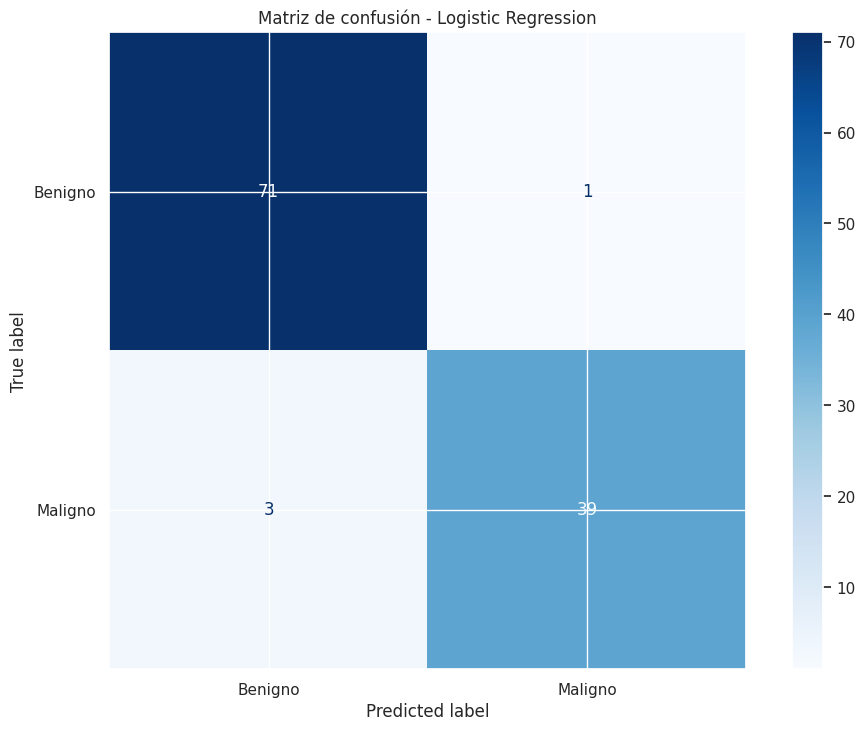


Entrenando modelo: SVM
Mejores parámetros:
{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

Classification report:
              precision    recall  f1-score   support

     Benigno       0.95      1.00      0.97        72
     Maligno       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



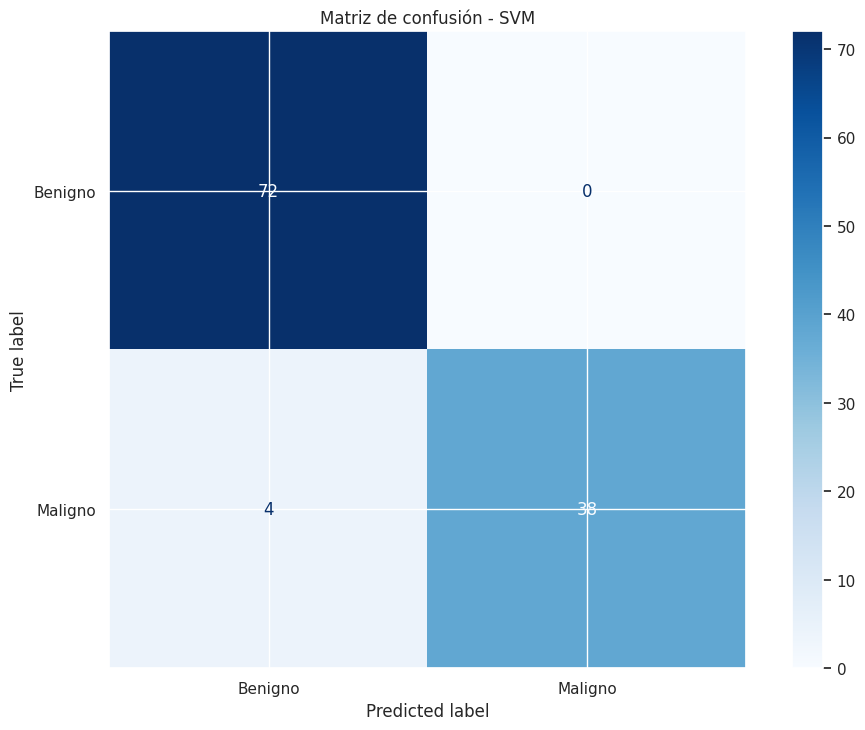


Entrenando modelo: Random Forest
Mejores parámetros:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Classification report:
              precision    recall  f1-score   support

     Benigno       0.93      0.99      0.96        72
     Maligno       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



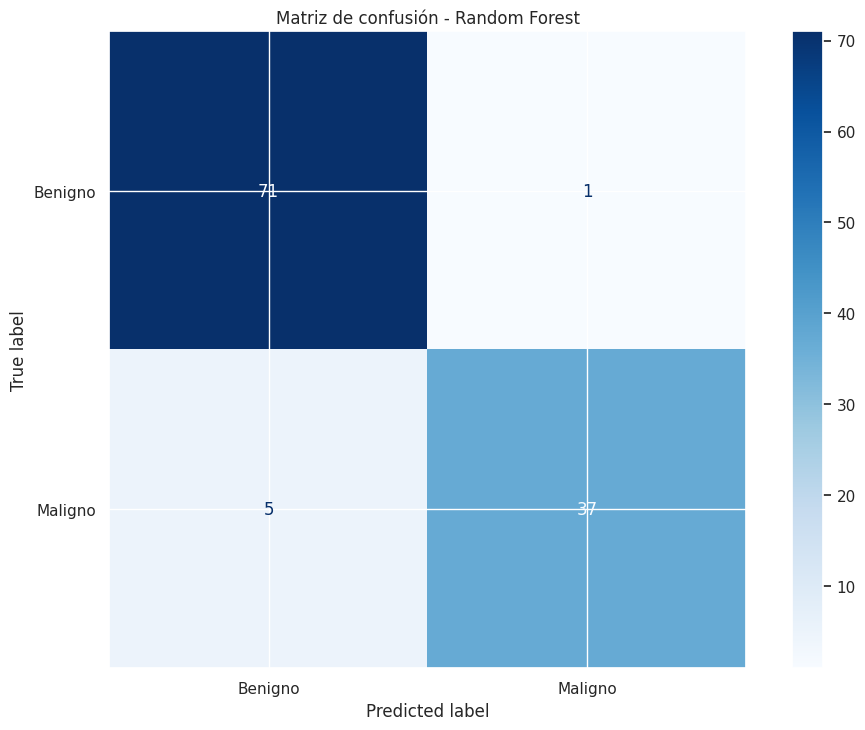


Entrenando modelo: KNN
Mejores parámetros:
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}

Classification report:
              precision    recall  f1-score   support

     Benigno       0.92      0.97      0.95        72
     Maligno       0.95      0.86      0.90        42

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



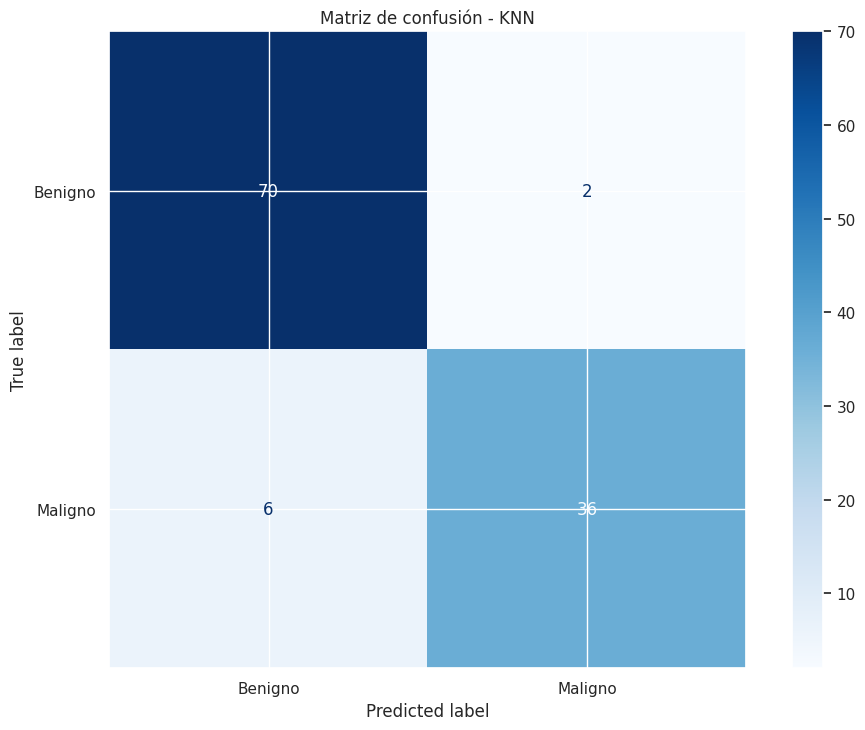


Comparación final de modelos:


,modelo,mejores_parametros,accuracy,precision,recall,f1,auc_roc
0,Logistic Regression,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",0.964912,0.975000,0.928571,0.95122,0.995370
1,SVM,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",0.964912,1.000000,0.904762,0.95000,0.993386
2,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.947368,0.973684,0.880952,0.92500,0.993552
3,KNN,"{'metric': 'euclidean', 'n_neighbors': 7, 'wei...",0.929825,0.947368,0.857143,0.90000,0.977844



Mejor modelo según F1-score: Logistic Regression


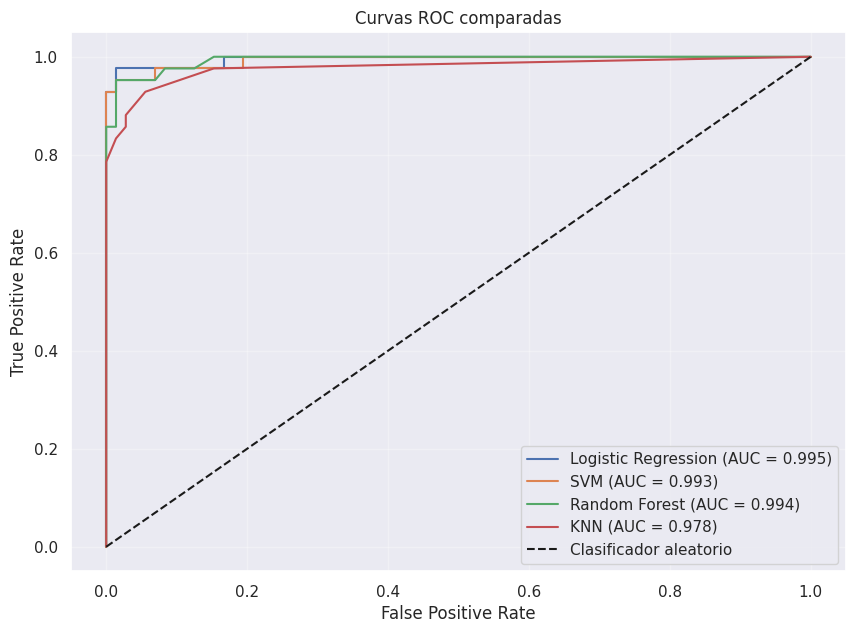


El mejor modelo no es Random Forest. Para interpretar variables se revisan coeficientes si el modelo es lineal.


,variable,coeficiente,abs_coeficiente
8,radius_se,2.343502,2.343502
0,radius_mean,1.746309,1.746309
16,texture_worst,1.412272,1.412272
5,concave points_mean,1.340206,1.340206
21,symmetry_worst,1.138548,1.138548
4,concavity_mean,0.977333,0.977333
19,concavity_worst,0.895087,0.895087
20,concave points_worst,0.837090,0.837090
11,compactness_se,-0.733275,0.733275
9,texture_se,-0.497962,0.497962


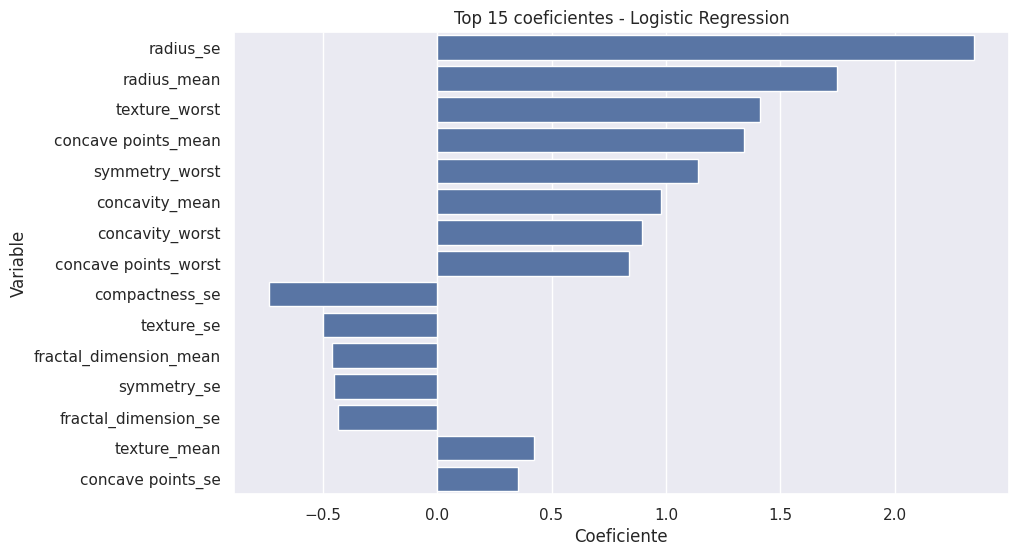

In [15]:
# 4. Modelado y evaluación

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    roc_curve
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# Modelos y grillas de hiperparámetros
modelos_grid = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=5000, random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10, 100],
            "penalty": ["l2"],
            "solver": ["liblinear"]
        }
    },
    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "C": [0.1, 1, 10, 100],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 3, 5, 10],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9, 11],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"]
        }
    }
}

resultados = []
mejores_modelos = {}

for nombre, config in modelos_grid.items():
    print("\n" + "="*80)
    print(f"Entrenando modelo: {nombre}")

    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        scoring="f1",
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    mejor_modelo = grid.best_estimator_
    mejores_modelos[nombre] = mejor_modelo

    y_pred = mejor_modelo.predict(X_test)
    y_proba = mejor_modelo.predict_proba(X_test)[:, 1]

    resultados.append({
        "modelo": nombre,
        "mejores_parametros": grid.best_params_,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc_roc": roc_auc_score(y_test, y_proba)
    })

    print("Mejores parámetros:")
    print(grid.best_params_)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["Benigno", "Maligno"]))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benigno", "Maligno"]
    )
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

resultados_modelos = pd.DataFrame(resultados).sort_values("f1", ascending=False)

print("\nComparación final de modelos:")
display(resultados_modelos)

# Mejor modelo por F1
mejor_nombre = resultados_modelos.iloc[0]["modelo"]
mejor_modelo = mejores_modelos[mejor_nombre]

print(f"\nMejor modelo según F1-score: {mejor_nombre}")

# Curvas ROC comparadas
plt.figure(figsize=(10, 7))

for nombre, modelo in mejores_modelos.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
plt.title("Curvas ROC comparadas")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Importancia de variables para modelos interpretables
if mejor_nombre == "Random Forest":
    importancias = pd.DataFrame({
        "variable": X_train.columns,
        "importancia": mejor_modelo.feature_importances_
    }).sort_values("importancia", ascending=False)

    print("\nImportancia de variables según Random Forest:")
    display(importancias.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importancias.head(15), x="importancia", y="variable")
    plt.title("Top 15 variables más importantes - Random Forest")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.show()
else:
    print("\nEl mejor modelo no es Random Forest. Para interpretar variables se revisan coeficientes si el modelo es lineal.")
    if hasattr(mejor_modelo, "coef_"):
        coeficientes = pd.DataFrame({
            "variable": X_train.columns,
            "coeficiente": mejor_modelo.coef_[0]
        })
        coeficientes["abs_coeficiente"] = coeficientes["coeficiente"].abs()
        coeficientes = coeficientes.sort_values("abs_coeficiente", ascending=False)

        display(coeficientes.head(15))

        plt.figure(figsize=(10, 6))
        sns.barplot(data=coeficientes.head(15), x="coeficiente", y="variable")
        plt.title(f"Top 15 coeficientes - {mejor_nombre}")
        plt.xlabel("Coeficiente")
        plt.ylabel("Variable")
        plt.show()

Se entrenaron y compararon cuatro modelos de clasificación: Regresión Logística, SVM, Random Forest y KNN. Para cada uno se aplicó optimización de hiperparámetros mediante validación cruzada, evaluando el desempeño con accuracy, precision, recall, F1-score y AUC-ROC.

El mejor modelo según F1-score fue **Logistic Regression**, con un **accuracy de 0,9649**, **precision de 0,9750**, **recall de 0,9286**, **F1-score de 0,9512** y **AUC-ROC de 0,9954**. Esto indica que el modelo logra un desempeño muy alto y mantiene un buen equilibrio entre precisión y detección de tumores malignos.

SVM obtuvo un desempeño muy similar, con accuracy de **0,9649**, precision de **1,0000**, recall de **0,9048**, F1-score de **0,9500** y AUC-ROC de **0,9934**. Aunque SVM no tuvo falsos positivos para la clase maligna, su recall fue menor que el de Regresión Logística, lo que significa que dejó pasar más casos malignos como benignos.

Random Forest presentó un F1-score de **0,9250** y KNN un F1-score de **0,9000**, ambos inferiores a Regresión Logística y SVM. Por lo tanto, aunque todos los modelos tuvieron buen rendimiento, los modelos lineales fueron los más efectivos en este conjunto de datos.

Dado que en un problema médico es especialmente importante detectar correctamente los casos malignos, el recall es una métrica clave. En este sentido, Regresión Logística ofrece un mejor balance que SVM, porque mantiene alta precision y logra un recall más alto para los tumores malignos. Además, su AUC-ROC de **0,9954** indica una excelente capacidad para separar entre tumores benignos y malignos.


5. **Conclusiones y reflexiones:**

   * Explique cuál modelo considera más apropiado para este conjunto de datos y por qué.
   * Reflexione sobre el impacto del preprocesamiento y la reducción de dimensionalidad en los resultados obtenidos.
   * Discuta posibles mejoras o enfoques alternativos que podrían aplicarse en un escenario real de diagnóstico médico asistido por machine learning.



Resumen de resultados:


,modelo,mejores_parametros,accuracy,precision,recall,f1,auc_roc
0,Logistic Regression,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",0.964912,0.975000,0.928571,0.95122,0.995370
1,SVM,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",0.964912,1.000000,0.904762,0.95000,0.993386
2,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.947368,0.973684,0.880952,0.92500,0.993552
3,KNN,"{'metric': 'euclidean', 'n_neighbors': 7, 'wei...",0.929825,0.947368,0.857143,0.90000,0.977844



Mejor modelo seleccionado:
Logistic Regression

Métricas del mejor modelo:


,modelo,mejores_parametros,accuracy,precision,recall,f1,auc_roc
0,Logistic Regression,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",0.964912,0.975,0.928571,0.95122,0.99537



Cantidad de predicciones correctas e incorrectas:


,count
resultado,
Correcto,110
Incorrecto,4



Casos incorrectos:


,real,predicho,probabilidad_maligno,resultado
id,,,,
9112085,0,1,0.513367,Incorrecto
859983,1,0,0.059471,Incorrecto
874858,1,0,0.403527,Incorrecto
879523,1,0,0.431699,Incorrecto


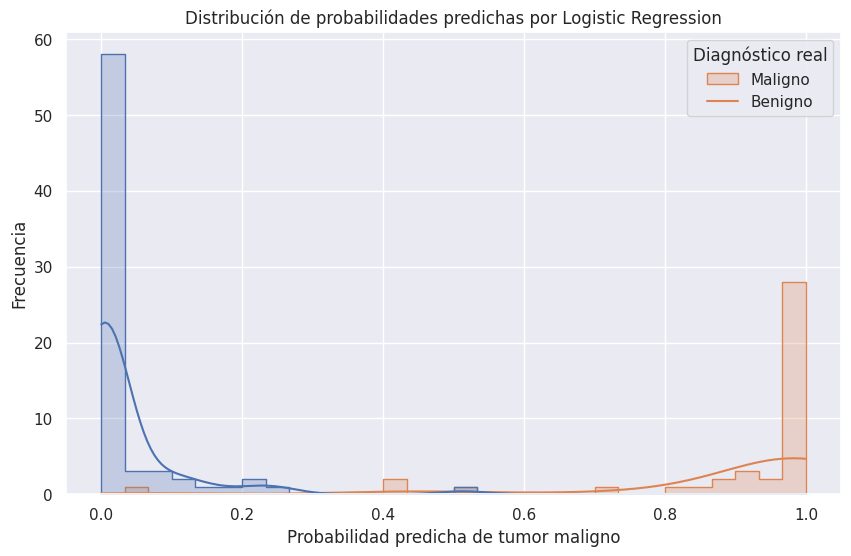

In [17]:
# 5. Conclusiones y reflexiones

# Resumen automático del mejor modelo
print("Resumen de resultados:")
display(resultados_modelos)

print("\nMejor modelo seleccionado:")
print(mejor_nombre)

print("\nMétricas del mejor modelo:")
display(resultados_modelos[resultados_modelos["modelo"] == mejor_nombre])

# Predicciones finales del mejor modelo
y_pred_final = mejor_modelo.predict(X_test)
y_proba_final = mejor_modelo.predict_proba(X_test)[:, 1]

# Casos correctos e incorrectos
df_predicciones = pd.DataFrame({
    "real": y_test.values,
    "predicho": y_pred_final,
    "probabilidad_maligno": y_proba_final
}, index=y_test.index)

df_predicciones["resultado"] = np.where(
    df_predicciones["real"] == df_predicciones["predicho"],
    "Correcto",
    "Incorrecto"
)

print("\nCantidad de predicciones correctas e incorrectas:")
display(df_predicciones["resultado"].value_counts())

print("\nCasos incorrectos:")
display(df_predicciones[df_predicciones["resultado"] == "Incorrecto"])

# Gráfico de probabilidades predichas
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_predicciones,
    x="probabilidad_maligno",
    hue="real",
    bins=30,
    kde=True,
    element="step"
)
plt.title(f"Distribución de probabilidades predichas por {mejor_nombre}")
plt.xlabel("Probabilidad predicha de tumor maligno")
plt.ylabel("Frecuencia")
plt.legend(title="Diagnóstico real", labels=["Maligno", "Benigno"])
plt.show()


Como el mejor modelo fue **Regresión Logística**, se revisaron sus coeficientes para identificar las variables con mayor influencia en la clasificación. Las variables con mayor peso absoluto fueron `radius_se`, `radius_mean`, `texture_worst`, `concave points_mean`, `symmetry_worst`, `concavity_mean`, `concavity_worst` y `concave points_worst`.

Los coeficientes positivos indican que, a medida que aumenta el valor de esas variables, aumenta la probabilidad estimada de que el tumor sea maligno. En particular, `radius_se` tuvo el mayor coeficiente positivo, con **2,3435**, seguido de `radius_mean`, con **1,7463**, y `texture_worst`, con **1,4123**. Esto sugiere que variaciones en el radio, textura y puntos cóncavos del tumor son especialmente importantes para distinguir tumores malignos.

Algunas variables aparecen con coeficientes negativos, como `compactness_se`, `texture_se`, `fractal_dimension_mean`, `symmetry_se` y `fractal_dimension_se`. Esto significa que, manteniendo constantes las demás variables, aumentos en esas características se asocian con una menor probabilidad estimada de malignidad dentro del modelo. Sin embargo, estos signos deben interpretarse con cautela, ya que las variables están estandarizadas y pueden existir relaciones entre características morfológicas.

El modelo seleccionado fue **Regresión Logística**, ya que obtuvo el mejor F1-score entre los modelos evaluados. Sus métricas fueron: accuracy de **0,9649**, precision de **0,9750**, recall de **0,9286**, F1-score de **0,9512** y AUC-ROC de **0,9954**. Estos resultados indican que el modelo tiene una alta capacidad para clasificar correctamente tumores benignos y malignos.

En el conjunto de prueba, el modelo realizó **110 predicciones correctas** y **4 predicciones incorrectas**. Entre los errores, hubo un caso benigno clasificado como maligno y tres casos malignos clasificados como benignos. Desde una perspectiva médica, los falsos negativos son especialmente relevantes, porque implican que un tumor maligno podría no ser detectado por el modelo.

Los casos incorrectos muestran probabilidades cercanas o inferiores al umbral de clasificación. Por ejemplo, un caso benigno fue clasificado como maligno con probabilidad de malignidad de **0,5134**, muy cerca del umbral de 0,5. En cambio, tres casos malignos fueron clasificados como benignos con probabilidades de malignidad de **0,0595**, **0,4035** y **0,4317**. Esto indica que algunos tumores malignos pueden presentar características similares a los benignos, generando errores de clasificación.

El preprocesamiento tuvo un rol importante en el resultado final. La estandarización permitió que modelos sensibles a escala funcionaran correctamente, y la eliminación de variables altamente correlacionadas redujo redundancia sin perder demasiada información. La reducción de dimensionalidad mostró que las clases presentan separación parcial en espacios reducidos, aunque no perfecta.

En un escenario real de diagnóstico médico asistido por Machine Learning, sería recomendable priorizar modelos con alto recall para la clase maligna, incluso si eso implica aceptar algunos falsos positivos. También sería importante validar el modelo con datos externos, revisar la calibración de probabilidades, ajustar el umbral de decisión y complementar la predicción con evaluación clínica especializada.

El laboratorio permitió desarrollar un flujo completo de Machine Learning supervisado para clasificación de tumores mamarios. Se comenzó con un análisis exploratorio, donde se observó que la base no tiene valores nulos ni duplicados y que las variables asociadas a tamaño, concavidad, puntos cóncavos, perímetro y área presentan alta capacidad para diferenciar tumores benignos y malignos.

Luego se aplicó un preprocesamiento adecuado mediante estandarización y eliminación de multicolinealidad. Esto permitió reducir el número de variables de 30 a 23, manteniendo la información más relevante y evitando redundancia excesiva.

La reducción de dimensionalidad con PCA mostró que 7 componentes explican más del 90% de la varianza y que las dos primeras componentes permiten una separación parcial entre diagnósticos. Además, t-SNE complementó el análisis al mostrar agrupamientos no lineales entre las clases.

Finalmente, se compararon cuatro modelos de clasificación con optimización de hiperparámetros. El mejor desempeño lo obtuvo **Regresión Logística**, con un F1-score de **0,9512** y un AUC-ROC de **0,9954**. El modelo logró clasificar correctamente 110 de 114 observaciones del conjunto de prueba.

En conclusión, los resultados muestran que es posible construir un modelo predictivo altamente efectivo para apoyar la clasificación de tumores mamarios. Sin embargo, dado que se trata de un contexto médico, el modelo no debe usarse como reemplazo del diagnóstico clínico, sino como una herramienta de apoyo. En aplicaciones reales, se debería validar con datos externos, priorizar la reducción de falsos negativos y trabajar junto a especialistas médicos.